In [44]:
import tempfile

from tqdm import tqdm_notebook
from transformers import AutoModelForCausalLM, AutoTokenizer
from minicons import scorer
from huggingface_hub import login

import pandas as pd
import os

import dotenv

dotenv.load_dotenv()


def load_hf_model(model_name: str, no_cache=False, **kwargs):
    model = None
    tokenizer = None
    token = os.environ["HF_TOKEN"]
    kwargs["token"] = token

    login(token)

    try:
        if no_cache:
            with tempfile.TemporaryDirectory() as tmpdirname:
                model = AutoModelForCausalLM.from_pretrained(
                    model_name, cache_dir=tmpdirname, **kwargs
                )
                tokenizer = AutoTokenizer.from_pretrained(
                    model_name, cache_dir=tmpdirname, **kwargs
                )
        else:
            model = AutoModelForCausalLM.from_pretrained(model_name, **kwargs)
            tokenizer = AutoTokenizer.from_pretrained(model_name, **kwargs)
    except OSError:
        raise
        pass

    if model is None:
        return None

    ilm_model = scorer.IncrementalLMScorer(
        model,
        "cuda",
        tokenizer=tokenizer,
    )

    return ilm_model

    
def score_tse(model, tse_df, sen="sen", wrong_sen="wrong_sen", attr_prefix="", verbose=1, max_length=128):
    tse_df["sen_prob"] = pd.Series(dtype=object).astype(object)
    tse_df["wrong_prob"] = pd.Series(dtype=object).astype(object)

    iterator = tqdm_notebook(tse_df.iterrows(), total=len(tse_df)) if verbose > 0 else tse_df.iterrows()

    for idx, row in iterator:
        sen_prob, wrong_prob = score_pair(model, row[sen], row[wrong_sen], max_length)

        if sen_prob is not None:
            sen_nll = -sen_prob.sum().item()
            wrong_nll = -wrong_prob.sum().item()

            tse_df.at[idx, "sen_prob"] = sen_prob.tolist()
            tse_df.at[idx, "wrong_prob"] = wrong_prob.tolist()

            tse_df.loc[idx, "sen_nll"] = sen_nll
            tse_df.loc[idx, "wrong_nll"] = wrong_nll
            tse_df.loc[idx, "delta"] = wrong_nll - sen_nll

    tse_df = tse_df[tse_df["delta"].notna()]

    return tse_df


def score_pair(ilm_model, sen, wrong_sen, max_length):
    sen_len = len(ilm_model.tokenizer.tokenize(sen))
    wrong_sen_len = len(ilm_model.tokenizer.tokenize(wrong_sen))

    if (max_length is not None) and (
        (sen_len >= max_length) or (wrong_sen_len >= max_length)
    ):
        return None, None

    stimuli = [sen, wrong_sen]

    return ilm_model.sequence_score(stimuli, reduction=lambda x: x)


def score_cols(model, df, cols, right_col, threshold=0.1):
    for col in cols:
        df[f"{col}_prob"] = pd.Series(dtype=object).astype(object)

    for idx, row in tqdm_notebook(df.iterrows(), total=len(df)):
        arg_cols = 
        sen_cols = [f"{arg}_sen_str" for arg in cols if row[f"{arg}_entropy"] < threshold]
        stimuli = row[sen_cols]
        
        model_probs = model.sequence_score(stimuli, reduction=lambda x: x)

        for col, prob in zip(cols, model_probs):
            df.at[idx, f"{col}_prob"] = prob.tolist()
            df.at[idx, f"{col}_nll"] = -prob.sum().item()

        for col in cols:
            right_nll = df.loc[idx][f"{right_col}_nll"]
            wrong_nll = df.loc[idx][f"{col}_nll"]
            df.at[idx, f"{col}_delta"] = wrong_nll - right_nll

    return df

In [2]:
# llm = load_hf_model("Qwen/Qwen3-0.6B", no_cache=True)
model_name = "google/gemma-3-1b-pt"
short_model_name = model_name.split("/")[-1]
llm = load_hf_model(model_name, no_cache=False)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [43]:
arg_df[arg_df.vso_entropy < 0.1]

,child_sibling-deprel_parataxis,child_sibling-feat_advmod_Degree,child_sibling-deprel_obl:arg,child_sibling-deprel-L_xcomp,child_sibling-feat_parataxis_VerbForm,child_sibling-feat_conj_Tense,child_sibling-feat_compound:prt_Number,child_sibling-pos_SYM,child_sibling-deprel-L_mark,child_sibling-feat_advcl_Gender,...,ovs_nll,osv_nll,vso_nll,vos_nll,svo_delta,sov_delta,ovs_delta,osv_delta,vso_delta,vos_delta
0,True,NaN,False,False,Fin,NaN,NaN,False,False,NaN,...,99.939438,114.529358,116.707024,122.099136,0.0,12.607834,2.733932,17.323853,19.501518,24.893631
1,False,NaN,False,False,NaN,Pres,NaN,False,False,NaN,...,147.959610,156.019699,148.358963,139.046021,0.0,8.743423,18.707993,26.768082,19.107346,9.794403
6,False,NaN,False,False,NaN,NaN,NaN,False,False,NaN,...,46.662373,60.882103,49.910175,58.875771,0.0,3.580975,-8.687740,5.531990,-5.439938,3.525658
7,False,Pos,False,False,NaN,NaN,NaN,False,False,NaN,...,144.516846,128.480011,162.567459,152.396194,0.0,8.553925,11.538116,-4.498718,29.588730,19.417465
12,False,NaN,False,False,NaN,NaN,NaN,False,False,NaN,...,111.989594,118.839920,103.480042,123.235764,0.0,24.181190,17.390839,24.241165,8.881287,28.637009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4469,False,NaN,False,False,NaN,Pres,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4471,False,NaN,False,False,NaN,NaN,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4472,False,NaN,False,False,NaN,NaN,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4474,False,NaN,False,False,NaN,NaN,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
from glob import glob
from pathlib import Path
import warnings
import pandas as pd

warnings.filterwarnings("ignore")

from collections import Counter

from src.word_order.entropy import order_entropy


glob_str = "/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/dt_df/*.csv"

for path in sorted(glob(glob_str)):
    lang = Path(path).stem
    
    swap_df = pd.read_csv(path)
    
    threshold = 0.1
    
    swap_df['has_swap'] = (
        (swap_df["svo_entropy"] < threshold)
        | (swap_df["sov_entropy"] < threshold)
        | (swap_df["ovs_entropy"] < threshold)
        | (swap_df["osv_entropy"] < threshold)
        | (swap_df["vso_entropy"] < threshold)
        | (swap_df["vos_entropy"] < threshold)
    )

    arg_dist = Counter(swap_df.core_args)
    most_common_freq = arg_dist.most_common(1)[0][1]
    other_freqs = sum(arg_dist.values()) - most_common_freq
    
    base_entropy = order_entropy(most_common_freq, other_freqs)

    if len(swap_df) < 15:
        continue
    
    print(lang, len(swap_df), base_entropy, swap_df['has_swap'].sum(), swap_df['has_swap'].mean()*100, (swap_df['leaf_entropy']<threshold).sum(), (swap_df['leaf_entropy']<threshold).mean()*100, sep='\t')

Abkhaz	41	0.8112781244591328	0	0.0	0	0.0
Afrikaans	203	0.6443000979570015	170	83.74384236453201	0	0.0
Akkadian	126	0.8548062777532202	87	69.04761904761905	0	0.0
Akuntsu	44	0.9942929346520455	0	0.0	0	0.0
Albanian	50	0.7335379291086666	0	0.0	0	0.0
Amharic	264	0.9919317412720596	210	79.54545454545455	0	0.0
Ancient Hebrew	415	0.9027533502965699	415	100.0	199	47.95180722891566
Ancient_Greek	4375	0.9309485297084945	200	4.571428571428571	4	0.09142857142857143
Ancient_Hebrew	415	0.9027533502965699	321	77.34939759036145	199	47.95180722891566
Apurina	45	0.20731018585948174	44	97.77777777777777	0	0.0
Arabic	623	0.9669770921413243	548	87.96147672552166	112	17.97752808988764
Armenian	128	0.9956608874301812	117	91.40625	0	0.0
Azerbaijani	22	0.4959690720618337	0	0.0	0	0.0
Basque	267	0.9999096087202762	0	0.0	3	1.1235955056179776
Bavarian	107	0.9895229905816816	45	42.05607476635514	0	0.0
Beja	23	0.9886994082884974	0	0.0	0	0.0
Belarusian	1398	0.6842498969833753	1108	79.25608011444922	10	0.71530758226037

1.0

In [45]:
swap_df = pd.read_csv("/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/dt_df/Dutch.csv")

keep_df = swap_df#[swap_df.keep]

arg2acc = {}
arg2df = {}

core_args = ["svo", "sov", "ovs", "osv", "vso", "vos"]

for arg, arg_df in keep_df.groupby("core_args"):
    print(arg)
    arg_df = score_cols(
        llm, 
        arg_df,
        cols=core_args,
        right_col=arg,
    )
    
    keep_df = arg_df.combine_first(keep_df)
    
    # acc = (df.delta > 0).mean()
    # print(arg, core_arg, acc)

    # arg2acc[arg, core_arg] = acc
    # arg2df[arg, core_arg] = df

osv


/tmp/ipykernel_67940/4279293699.py:1: DtypeWarning: Columns (16,30,34,58,62,76,77,93,107) have mixed types. Specify dtype option on import or set low_memory=False.
  swap_df = pd.read_csv("/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/WORD_ORDER/dt_df/Dutch.csv")
/tmp/ipykernel_67940/1665520050.py:95: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for idx, row in tqdm_notebook(df.iterrows(), total=len(df)):


  0%|          | 0/1 [00:00<?, ?it/s]

KeyError: 'osv_nll'

(array([  47., 2448.,    0.,    0.,  113.,    0.,    0.,    0.,    0.,
          50.]),
 array([0.        , 0.04912373, 0.09824747, 0.1473712 , 0.19649494,
        0.24561867, 0.29474241, 0.34386614, 0.39298987, 0.44211361,
        0.49123734]),
 <BarContainer object of 10 artists>)

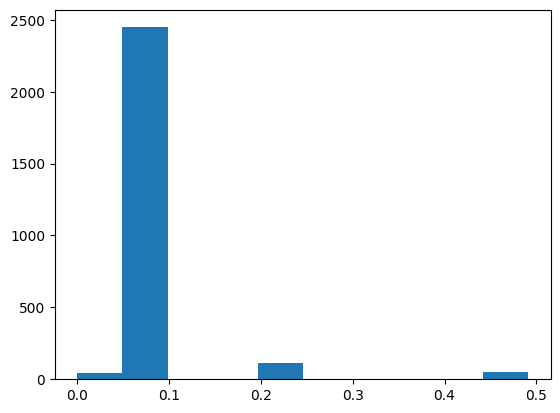

In [36]:
plt.hist(arg_df.vso_entropy)